# AQI Prediction: EDA and Model Training

This notebook focuses on exploring the Air Quality Index (AQI) data stored in the Hopsworks Feature Store and training multiple machine learning models to find the best predictor for `target_aqi`.

## 1. Setup and Environment

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import hopsworks
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

warnings.filterwarnings('ignore')
load_dotenv('../.env') # Load from project root

d:\AQI-Predictor\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

## 2. Connect to Hopsworks

In [2]:
project_name = os.getenv("HOPSWORKS_PROJECT_NAME")
api_key = os.getenv("HOPSWORKS_API_KEY")

project = hopsworks.login(project=project_name, api_key_value=api_key)
fs = project.get_feature_store()

2026-05-13 22:57:00,894 INFO: Initializing external client
2026-05-13 22:57:00,895 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-05-13 22:57:04,962 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/32029


## 3. Retrieve Data

In [3]:
# Fetch the feature group
fg_name = "aqi_features"
fg_version = 2
aqi_fg = fs.get_feature_group(name=fg_name, version=fg_version)

# Read data as a DataFrame
df = aqi_fg.read()
print(f"Data retrieved: {df.shape[0]} rows, {df.shape[1]} columns")

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.74s) 
Data retrieved: 798 rows, 20 columns


## 4. Exploratory Data Analysis (EDA)

In [4]:
# First few rows
df.head()

,city,timestamp,aqi,pm25,pm10,o3,no2,so2,co,temperature,humidity,pressure,wind_speed,target_aqi,target_day,hour,day,month,day_of_week,ingestion_timestamp
0,"Karachi US Consulate, Pakistan",2025-03-04 16:00:00+00:00,161.000000,161.000000,0.000000,0.000000,0.000000,0.000000,0.000000,31.000000,3.000000,1016.000000,5.100000,169.000000,2025-03-03,16,4,3,1,2026-05-07 13:53:09+00:00
1,"Karachi, Pakistan",2026-04-14 21:00:00+00:00,112.133226,89.706581,56.066613,17.774007,11.030647,7.522562,0.399704,21.464466,53.005802,1013.463121,5.436666,113.552162,2026-04-15,21,14,4,1,2026-04-14 21:00:00+00:00
2,"Karachi, Pakistan",2026-05-05 01:00:00+00:00,144.328748,115.462998,72.164374,14.339249,21.079273,6.606686,0.450879,26.294095,58.046619,1006.257579,9.203882,151.203956,2026-05-06,1,5,5,1,2026-05-05 01:00:00+00:00
3,"Karachi, Pakistan",2026-04-12 16:00:00+00:00,131.065038,104.852030,65.532519,19.701888,22.080205,6.292420,0.337642,20.669873,65.746495,1013.168342,9.403049,139.112017,2026-04-13,16,12,4,6,2026-04-12 16:00:00+00:00
4,"Karachi, Pakistan",2026-04-26 04:00:00+00:00,183.110765,146.488612,91.555382,14.229888,25.522864,2.933050,0.217595,29.330127,54.257666,1012.405458,5.540368,179.767608,2026-04-27,4,26,4,6,2026-04-26 04:00:00+00:00


In [5]:
# Summary statistics
df.describe()

,aqi,pm25,pm10,o3,no2,so2,co,temperature,humidity,pressure,wind_speed,target_aqi,hour,day,month,day_of_week
count,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000
mean,150.938715,123.857989,67.701813,11.409235,18.039508,5.469663,0.272190,25.573521,54.544461,1010.598140,5.436462,151.987745,11.944862,14.379699,4.110276,2.766917
std,22.767027,21.732960,24.839409,5.501604,8.070923,2.763424,0.141930,3.803232,17.694892,3.262089,2.525488,23.713347,6.718350,8.904481,0.539873,1.937754
min,93.252945,74.602356,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,3.000000,1005.005886,1.011326,90.514269,0.000000,1.000000,3.000000,0.000000
25%,133.339793,106.671834,62.063449,7.775376,13.161255,3.620588,0.173913,21.464466,53.604431,1007.667352,3.421243,133.619550,6.000000,6.000000,4.000000,1.000000
50%,152.972514,122.378011,73.015993,11.902122,18.971247,5.570465,0.277297,26.294095,59.293277,1010.493454,5.100000,154.167993,13.000000,14.000000,4.000000,3.000000
75%,167.614001,140.076184,83.807000,15.930169,24.462748,7.789890,0.389426,29.330127,64.242888,1013.315042,7.611433,169.436088,17.000000,22.000000,4.000000,4.000000
max,200.045258,161.000000,100.022629,19.984442,29.993051,9.992761,0.499720,31.000000,69.984129,1016.000000,9.977640,210.547877,23.000000,30.000000,5.000000,6.000000


In [6]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 798 entries, 0 to 797
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype                  
---  ------               --------------  -----                  
 0   city                 798 non-null    object                 
 1   timestamp            798 non-null    datetime64[us, Etc/UTC]
 2   aqi                  798 non-null    float64                
 3   pm25                 798 non-null    float64                
 4   pm10                 798 non-null    float64                
 5   o3                   798 non-null    float64                
 6   no2                  798 non-null    float64                
 7   so2                  798 non-null    float64                
 8   co                   798 non-null    float64                
 9   temperature          798 non-null    float64                
 10  humidity             798 non-null    float64                
 11  pressure             798 non-nul

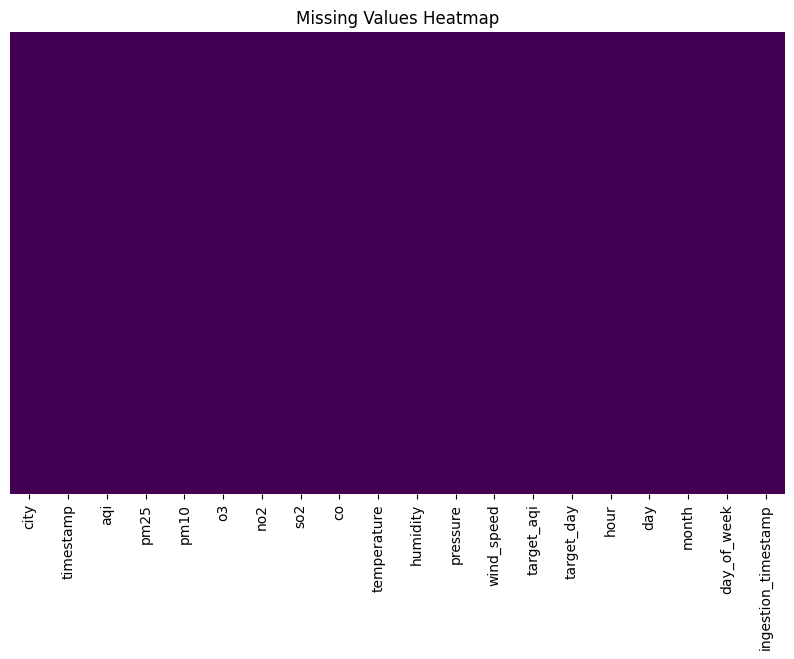

In [7]:
# Check for missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

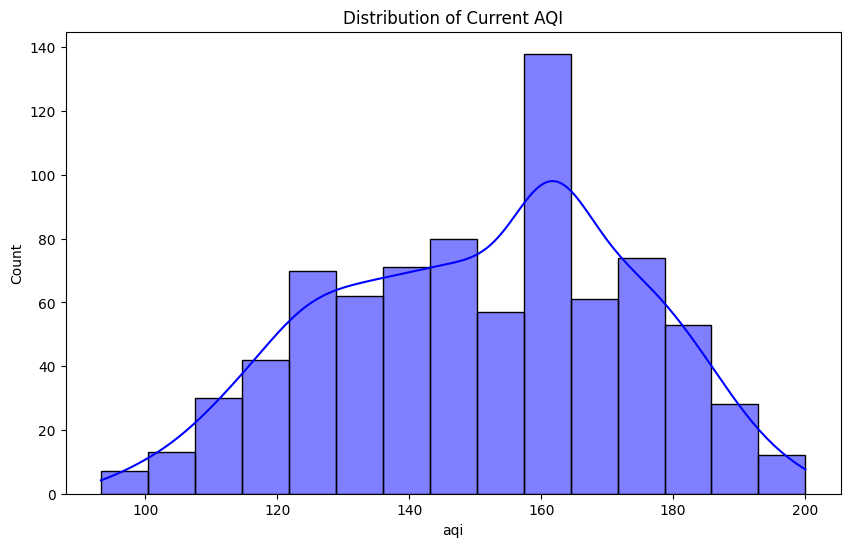

In [8]:
# Distribution of AQI (Target Variable)
plt.figure(figsize=(10, 6))
sns.histplot(df['aqi'], kde=True, color='blue')
plt.title('Distribution of Current AQI')
plt.show()

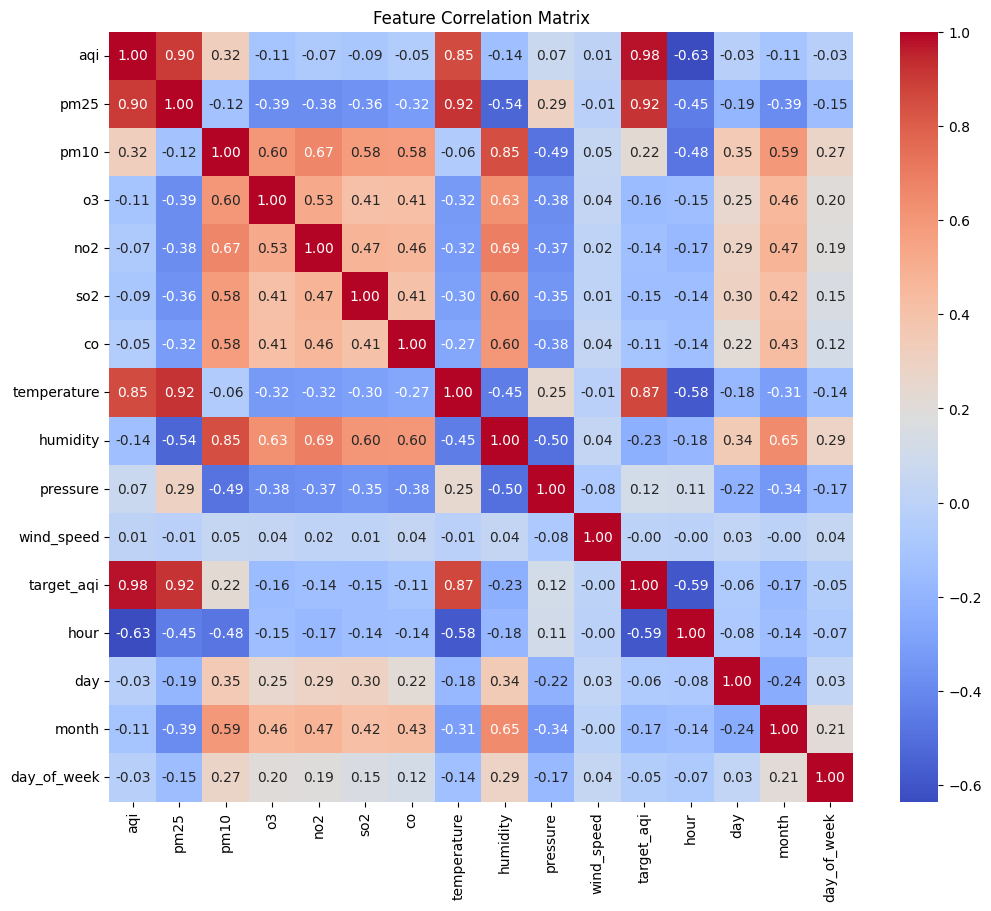

In [9]:
# Correlation Heatmap
plt.figure(figsize=(12, 10))
numerical_df = df.select_dtypes(include=[np.number])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

## 5. Data Preprocessing

In [11]:
# Features and Target
# We'll exclude identifiers and future timestamps
drop_cols = ['city', 'timestamp', 'ingestion_timestamp', 'target_day', 'target_aqi']
X = df.drop(columns=drop_cols, errors='ignore')
y = df['target_aqi']

print(f"Features: {list(X.columns)}")
print(f"Target: target_aqi")

Features: ['aqi', 'pm25', 'pm10', 'o3', 'no2', 'so2', 'co', 'temperature', 'humidity', 'pressure', 'wind_speed', 'hour', 'day', 'month', 'day_of_week']
Target: target_aqi


In [12]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (638, 15), Test shape: (160, 15)


## 6. Model Training and Comparison

In [13]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2
    })
    
results_df = pd.DataFrame(results).sort_values(by="RMSE")

## 7. Results and Conclusion

In [14]:
# Display results
print("Model Comparison Results:")
display(results_df)

Model Comparison Results:


,Model,RMSE,MAE,R2 Score
0,Linear Regression,4.806477,3.776474,0.959114
3,XGBoost,4.812745,3.638217,0.959007
1,Random Forest,4.936897,3.786169,0.956865
2,Gradient Boosting,4.991497,3.854502,0.955906


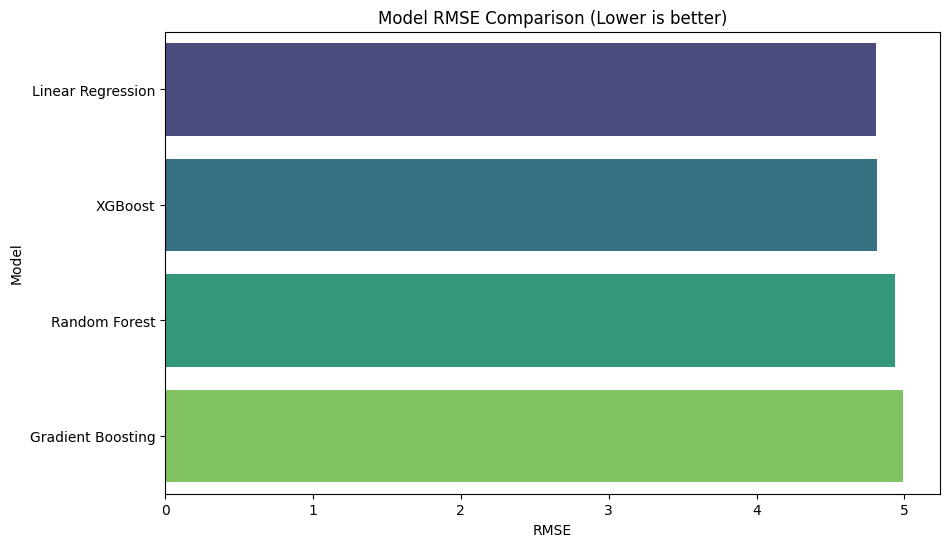

In [15]:
# Visualize RMSE comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='RMSE', y='Model', data=results_df, palette='viridis')
plt.title('Model RMSE Comparison (Lower is better)')
plt.show()

In [16]:
# Identify best model
best_model_name = results_df.iloc[0]['Model']
print(f"The best model is: {best_model_name}")

The best model is: Linear Regression
